<a href="https://colab.research.google.com/github/Giorgosman13/RL_Assignment2/blob/main/Assignment_2_Reverse_Engineering_Non_Stationarity_and_Price_Wars!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Reverse Engineering Non-Stationarity and Price Wars!

Author: *Giorgos Vassalos 2022030052*

# Initialization

First we need to import the necessary libraries and create the 2 arms that the environment sets us.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

n_arms = 2
arms = [0,1]

We create the environment of the first part of the assignment. To be more specific we create the non stationary environment (an environment without determined rewards that change over time). The function step returns us the reward at a certain time for a certain arm of the environment. And it works in a way to automatically change the state of the arm between the low and the high for each t.

In [41]:
class Environment:
  def __init__(self,p_L,p_H,t_L,t_H,initial_states):
    self.count = [0,0]
    self.p_l = p_L
    self.p_h = p_H
    self.t_l = t_L
    self.t_h = t_H
    self.initial_states = initial_states

  def step (self,arm):
    # 1. Determine reward for the chosen arm BEFORE updating states
    current_state = self.initial_states[arm]
    p_a = self.p_l[arm] if current_state == "Low" else self.p_h[arm]
    r = np.random.binomial(1, p_a)

    # 2. Update the internal state of ALL arms (Independent Evolution)
    for i in range(2):
      self.count[i] += 1
      limit = self.t_l[i] if self.initial_states[i] == "Low" else self.t_h[i]

      if self.count[i] >= limit:
        # Toggle state: Low -> High or High -> Low
        self.initial_states[i] = "High" if self.initial_states[i] == "Low" else "Low"
        self.count[i] = 0
    return r


Here we make a simple Explore then Exploit algorithm. It takes as arguments the horizon T and the environment to find the optimal N. That is:
\begin{equation}
N = \left\lfloor \left( \frac{T}{n_{\text{arms}}} \right)^{\frac{2}{3}} \right\rfloor
\end{equation}
We then play each arm N/num_arms times to find the optimal arm of the EtE algorithm and then play the one with the maximum reward.

In [42]:
def run_ExploreThenExploit(T,env):
  N = np.power(T/n_arms,2/3).astype(int)

  r_in = np.zeros(n_arms)
  rewards = np.zeros(T)

  arm_selected = np.zeros(n_arms)

  for t in range(T):
    if t <= N:
      arm_i = t % n_arms
    else:
      arm_i = np.argmax(r_in)

    r = env.step(arm_i)
    r_in[arm_i] += r

    arm_selected[arm_i] += 1
    if t == 0:
      rewards[t] = r
    else:
      rewards[t] = r + rewards[t-1]

  return rewards, arm_selected


For our UCB algorithm we use the one we created in the previous assignment with the main difference being we get the cummulitive reward for each step and not the regret. Another minor difference is that the UCB algorithm now doesn't have the Rmax since rewards are already from 0 to 1.

In [43]:
def run_UCB(T, env):
  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  Xin = np.zeros(n_arms)
  rin = np.zeros(n_arms)
  mu_hat = np.zeros(n_arms)

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    r = env.step(arm_i)
    #What our algorithm has access to:
    rin[arm_i] += r
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    arm_selected[arm_i] += 1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward,arm_selected

Here we create a Multiplicative weights algorithm for our environment. We make it robust by using an epsilon value (exploration value) so even if it thinks it has a correct hand according to the weights it will still try to use some other arm to get rid of the chance we get an infinite estimated loss due to really small pi. Other than that it is the usual MW bandit that is known for its ability to perform well even against adversarsial bandits.

In [44]:
def run_MWbandit(T, env, epsilon=0.1):
  weights = np.ones(n_arms)
  ita = np.sqrt(np.log(n_arms)/T)
  k = n_arms

  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  for t in range(T):

    weights_sum = np.sum(weights)
    pi = weights / weights_sum

    # Mix with uniform: q_i = (1-ε)*p_i + ε/k
    q = (1 - epsilon) * pi + epsilon / k

    # Sample using q instead of p
    arm_i = np.random.choice(n_arms, p=q)

    r = env.step(arm_i)
    l = 1 - r

    # Unbiased loss estimate using q_i (only for picked arm, 0 for others)
    est_loss = l / q[arm_i]

    # Update weights using pi (the MW distribution, not q)
    weights[arm_i] *= np.exp(-ita * est_loss)

    arm_selected[arm_i] += 1

    if t == 0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward, arm_selected

# Task A.1

Here we run the above algorithms with the sanity check variables for the environment more specifically we set pl and ph the same for both arms so there is a better and a worse arm that remains better or worse. That has as a result that all 3 algorithms work as planned and have good rewards and small regrets.

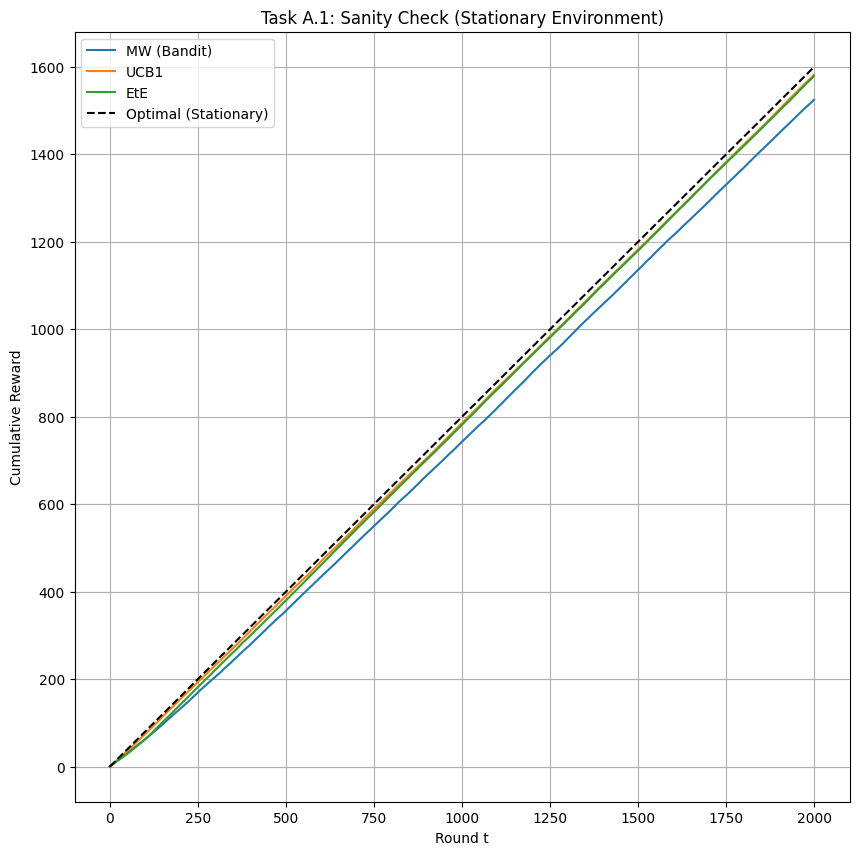

Final Rewards (Mean ± Std):
MW:  1524.40 ± 13.32
UCB: 1581.60 ± 18.26


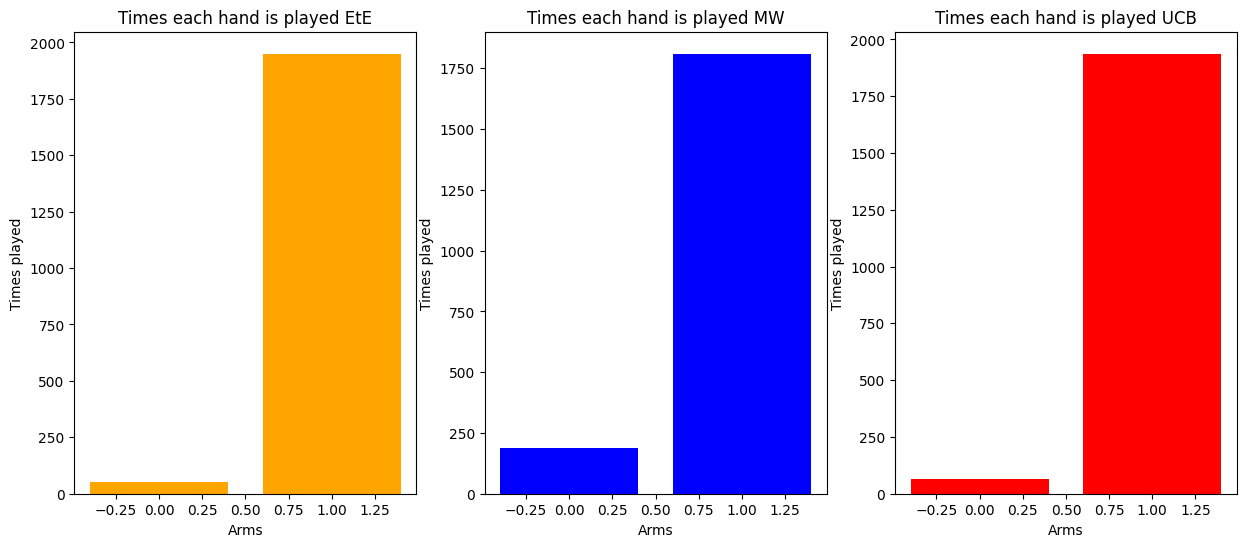

In [45]:
#Sanity check variables:
T = 2000

p_l = [0.4,0.8]
p_h = [0.4,0.8]

t_l = [50,30]
t_h = [25, 50]

initial_states = ["Low", "High"]



mc_runs = 20

rewards_mw = np.zeros((mc_runs,T))
rewards_ucb = np.zeros((mc_runs,T))
rewards_ete = np.zeros((mc_runs,T))

arms_selected_mw = np.zeros((mc_runs, n_arms))
arms_selected_ucb = np.zeros((mc_runs, n_arms))
arms_selected_ete = np.zeros((mc_runs, n_arms))

for m in range(mc_runs):
  np.random.seed(m)
  env_mw = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ete = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ucb = Environment(p_l, p_h, t_l, t_h, initial_states)

  rewards_ete[m,:], arms_selected_ete[m,:] = run_ExploreThenExploit(T, env_ete)
  rewards_ucb[m,:], arms_selected_ucb[m,:] = run_UCB(T, env_ucb)
  rewards_mw[m,:], arms_selected_mw[m,:] = run_MWbandit(T, env_mw)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)
mean_ete = np.mean(rewards_ete, axis=0)

mean_selection_mw = np.mean(arms_selected_mw, axis=0)
mean_selection_ucb = np.mean(arms_selected_ucb, axis=0)
mean_selection_ete = np.mean(arms_selected_ete, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB1')
plt.plot(mean_ete, label='EtE')
plt.plot([0, T], [0, 0.8*T], 'k--', label='Optimal (Stationary)')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task A.1: Sanity Check (Stationary Environment)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Values (Mean ± Std) [cite: 3, 42]
print(f"Final Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")

plt.figure(figsize=(15,6))
arm_indices = np.arange(n_arms)
plt.subplot(1,3,1)
plt.bar(arm_indices, mean_selection_ete, color = 'orange')
plt.title("Times each hand is played EtE")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,3,2)
plt.bar(arm_indices, mean_selection_mw, color = 'blue', label = 'Multiplicative Weights')
plt.title("Times each hand is played MW")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,3,3)
plt.bar(arm_indices, mean_selection_ucb, color = 'red', label = 'UCB')
plt.title("Times each hand is played UCB")
plt.xlabel("Arms")
plt.ylabel("Times played")
plt.show()

# Task A.2

We can notice that an environment is easily exploitable especially vs an explore then exploit algorithm. We should make the time where an arm seems good be the same as N and then for the rest time just change it to be the worse arm so if we suppose arm 1 is the best we put t_h[arm0] = N and t_l[arm1] = N while the opposite are: t_l[arm0] >>>N and t_h[arm1]>>>N so if we make the environment as such the algorithm is confused and plays the wrong hand while the MW algorithm doesnt get confused since with the ever changing weights as well as the occasional random play it can pick the correct arm over time.

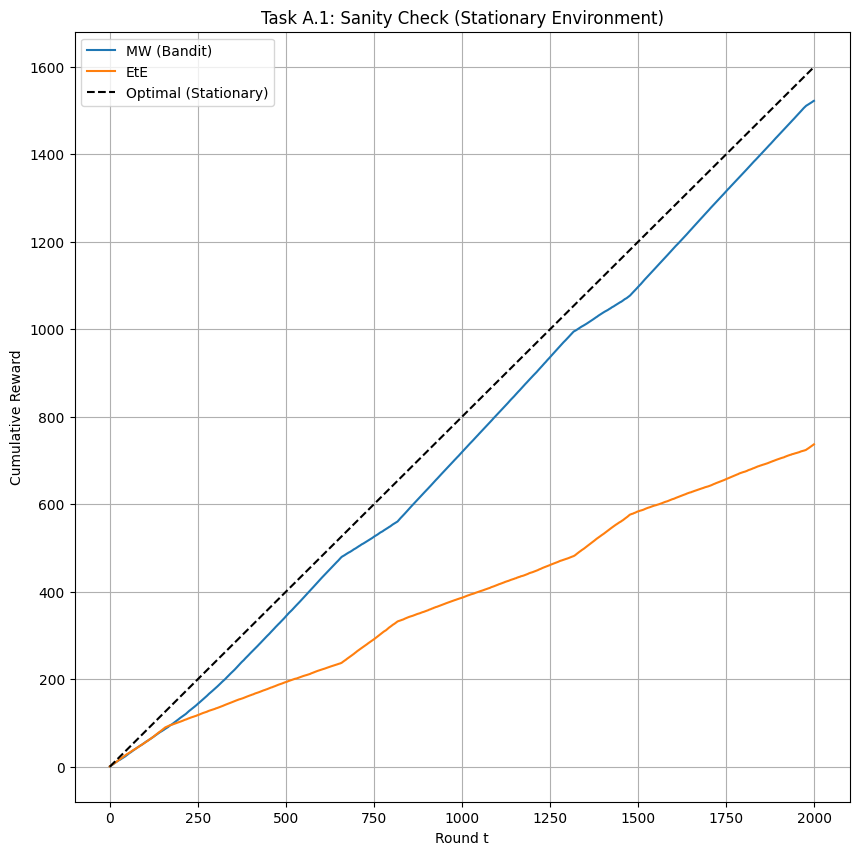

Final Rewards (Mean ± Std):
MW:  1522.05 ± 25.64


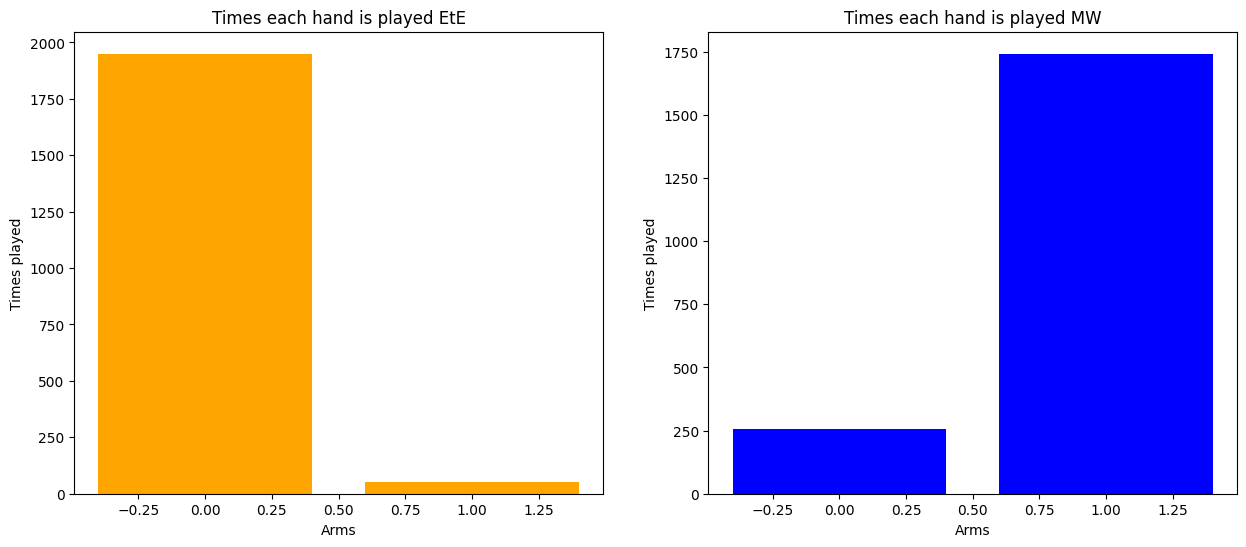

In [46]:
T = 2000

p_l = [0.3,0.5]
p_h = [0.6,0.9]

N = np.power(T,2/3)

t_l = [500,N]
t_h = [N, 500]

initial_states = ["High", "Low"]



mc_runs = 20

rewards_mw = np.zeros((mc_runs,T))
rewards_ete = np.zeros((mc_runs,T))

arms_selected_mw = np.zeros((mc_runs, n_arms))
arms_selected_ete = np.zeros((mc_runs, n_arms))

for m in range(mc_runs):
  np.random.seed(m)
  env_mw = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ete = Environment(p_l, p_h, t_l, t_h, initial_states)

  rewards_ete[m,:], arms_selected_ete[m,:] = run_ExploreThenExploit(T, env_ete)
  rewards_mw[m,:], arms_selected_mw[m,:] = run_MWbandit(T, env_mw)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ete = np.mean(rewards_ete, axis=0)

mean_selection_mw = np.mean(arms_selected_mw, axis=0)
mean_selection_ete = np.mean(arms_selected_ete, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ete, label='EtE')
plt.plot([0, T], [0, 0.8*T], 'k--', label='Optimal (Stationary)')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task A.1: Sanity Check (Stationary Environment)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Values (Mean ± Std) [cite: 3, 42]
print(f"Final Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")


plt.figure(figsize=(15,6))
arm_indices = np.arange(n_arms)
plt.subplot(1,2,1)
plt.bar(arm_indices, mean_selection_ete, color = 'orange')
plt.title("Times each hand is played EtE")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,2,2)
plt.bar(arm_indices, mean_selection_mw, color = 'blue', label = 'Multiplicative Weights')
plt.title("Times each hand is played MW")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.show()

# Part B

We start with the initialization of the environment by creating the arms of our learner and sorting them from smaller to larger.

In [47]:
SEED = 52
np.random.seed(SEED)
K=20 #Num of arms

#Learner arms
p = np.sort(np.random.uniform(0, 5, K))

Here we create the algorithm that returns us if the customer chose the learner or the competitor according to the equation that was given to us by the assignment.

In [48]:
#Returns true if the learner is chosen false if the competitor
def customer_Choice(beta, pt, qt):

  pr_l= 1.0/(1.0+np.exp(beta*(pt-qt)))
  return np.random.rand() < pr_l

In this block we create a function that calculates the expected reward of the competitor according to a set choice made by the learner. Then we take that expected reward and we use that to find the maximum value it can take using scipy's function optimize.minimize_Scala and then return it

In [49]:
def expected_reward(qt, beta, learner_choice):
    pr_c = 1.0/(1.0+np.exp(-beta*(learner_choice-qt)))
    return qt*pr_c

def competitor_choice_UCB(beta, ucb_choice):
#There is only a minimize function so we need to minimize -reward to find the maximum
  def objective(qt):
    return -expected_reward(qt, beta, ucb_choice)

  optimal_price = scipy.optimize.minimize_scalar(objective,bounds = [0.01, 10], method = 'bounded')
  return optimal_price.x


In a similar way we make the competitor choose for the multiplicative weights algorithm, however it doesn't have access to what the learner chose so we need to calculate the expected reward for the sum of all arms and find what competitor choice gives us the highest total expected reward for the competitor. We return the qt that returns the highest total expected reward.

In [50]:
def competitor_choice_MW(beta, MW_probabilities, arms):
  def objective(qt):
    total_r = 0.0

    for (pr, arm) in zip(MW_probabilities, arms):
      total_r += pr * expected_reward(qt, beta, arm)
    return -total_r

  optimal_price = scipy.optimize.minimize_scalar(objective,bounds = [0.01, 10], method = 'bounded')
  return optimal_price.x

Our learner algorithms work in the same way the algorithms of part A worked so I don't need to explain them further except from we added the competitor making a choice inside the algorithm as well as the learner recieving a reward only if it is chosen


In [51]:
def run_UCB_learner(T, beta):
  reward = np.zeros(T)
  price_selected_UCB = np.zeros(T)
  price_selected_Comp = np.zeros(T)

  Xin = np.zeros(K)
  rin = np.zeros(K)
  mu_hat = np.zeros(K)

  for t in range(T):
    if t<K:
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    qt = competitor_choice_UCB(beta, p[arm_i])
    if(customer_Choice(beta, p[arm_i], qt)):
      r = p[arm_i]
    else:
      r = 0
    #What our algorithm has access to:
    rin[arm_i] += r
    Xin[arm_i] += 1
    mu_hat[arm_i] = rin[arm_i] / Xin[arm_i]

    price_selected_UCB[t] = p[arm_i]
    price_selected_Comp[t] = qt

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward, price_selected_Comp, price_selected_UCB

In [52]:
def run_MW_learner(T, beta, epsilon=0.1):
  weights = np.ones(K)
  ita = np.sqrt(np.log(K)/T)

  reward = np.zeros(T)
  price_selected_MW = np.zeros(T)
  price_selected_Comp = np.zeros(T)

  for t in range(T):

    weights_sum = np.sum(weights)
    pi = weights / weights_sum

    q = (1 - epsilon) * pi + epsilon / K

    arm_i = np.random.choice(K, p=q)

    qt = competitor_choice_MW(beta, q, p)
    if(customer_Choice(beta, p[arm_i], qt)):
      r = p[arm_i]
    else:
      r = 0

    l = 1 - r

    est_loss = l / q[arm_i]

    weights[arm_i] *= np.exp(-ita * est_loss)

    price_selected_MW[t] = p[arm_i]
    price_selected_Comp[t] = qt

    if t == 0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward, price_selected_Comp, price_selected_MW

Here we have a low beta so a low dependancy on price and a higher dependancy on brand trust or other factors so we can see that the UCB performs just as well as the multiplicative bandits since there is not a large need to adapt to how the competition is behaving and is consistently playing the best arm. It also is helped by the fact that the consumer does not care about the price. That is proven by the graphs below.

In [53]:
beta = 0.5
MC_runs= 20
T=2000

rewards_mw = np.zeros((MC_runs,T))
rewards_ucb = np.zeros((MC_runs,T))

price_selected_mw = np.zeros((MC_runs, T))
price_selected_ucb = np.zeros((MC_runs, T))

price_selected_comp_mw = np.zeros((MC_runs, T))
price_selected_comp_ucb = np.zeros((MC_runs, T))

for m in range(MC_runs):
  np.random.seed(m)

  rewards_mw[m,:], price_selected_comp_mw[m,:], price_selected_mw[m, :] = run_MW_learner(T, beta)
  rewards_ucb[m,:], price_selected_comp_ucb[m,:], price_selected_ucb[m,:] = run_UCB_learner(T, beta)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)

mean_selection_mw = np.mean(price_selected_mw, axis=0)
mean_selection_ucb = np.mean(price_selected_ucb, axis=0)

mean_selection_comp_mw = np.mean(price_selected_comp_mw, axis=0)
mean_selection_comp_ucb = np.mean(price_selected_comp_ucb, axis=0)

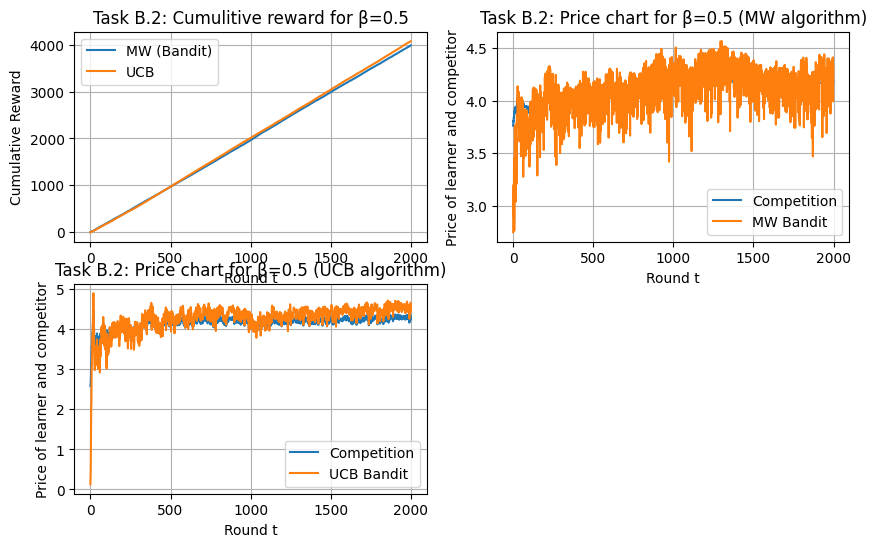

Final Cumulative Rewards (Mean ± Std):
MW:  3985.40 ± 168.21
UCB: 4074.73 ± 125.37


In [54]:
plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task B.2: Cumulitive reward for β=0.5')
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(mean_selection_comp_mw, label='Competition')
plt.plot(mean_selection_mw, label='MW Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=0.5 (MW algorithm)')
plt.legend()
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(mean_selection_comp_ucb, label='Competition')
plt.plot(mean_selection_ucb, label='UCB Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=0.5 (UCB algorithm)')
plt.legend()
plt.grid(True)

plt.show()

print("Final Cumulative Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")


In this environment we set beta = 5 which is a medium care about the price of the product. We can safely guess that this time the UCB algorithm is going to get outdone by the MW algorithm since the MW algorithm can easily adapt to the competitor playing the better arm due to its insider information.

In [55]:
beta = 5
MC_runs= 20
T=2000

rewards_mw = np.zeros((MC_runs,T))
rewards_ucb = np.zeros((MC_runs,T))

price_selected_mw = np.zeros((MC_runs, T))
price_selected_ucb = np.zeros((MC_runs, T))

price_selected_comp_mw = np.zeros((MC_runs, T))
price_selected_comp_ucb = np.zeros((MC_runs, T))

for m in range(MC_runs):
  np.random.seed(m)

  rewards_mw[m,:], price_selected_comp_mw[m,:], price_selected_mw[m, :] = run_MW_learner(T, beta)
  rewards_ucb[m,:], price_selected_comp_ucb[m,:], price_selected_ucb[m,:] = run_UCB_learner(T, beta)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)

mean_selection_mw = np.mean(price_selected_mw, axis=0)
mean_selection_ucb = np.mean(price_selected_ucb, axis=0)

mean_selection_comp_mw = np.mean(price_selected_comp_mw, axis=0)
mean_selection_comp_ucb = np.mean(price_selected_comp_ucb, axis=0)

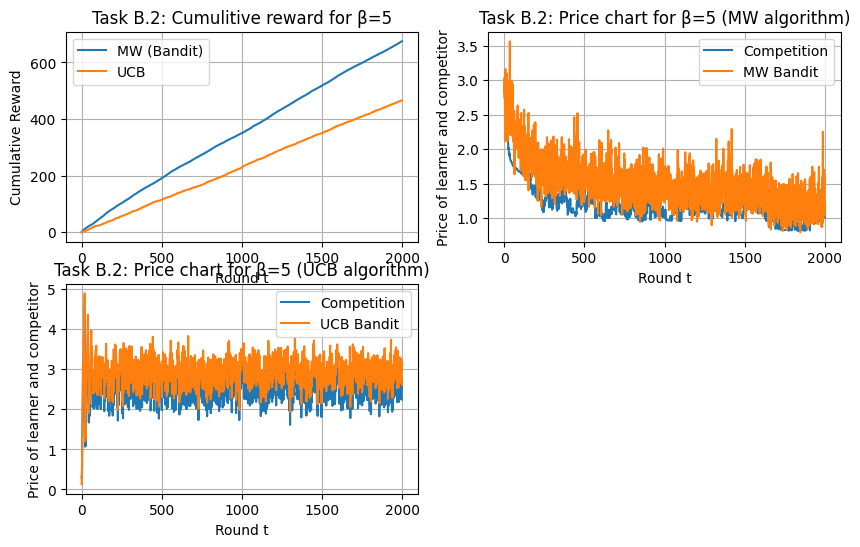

Final Cumulative Rewards (Mean ± Std):
MW:  675.02 ± 56.91
UCB: 465.99 ± 28.43


In [56]:
plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task B.2: Cumulitive reward for β=5')
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(mean_selection_comp_mw, label='Competition')
plt.plot(mean_selection_mw, label='MW Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=5 (MW algorithm)')
plt.legend()
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(mean_selection_comp_ucb, label='Competition')
plt.plot(mean_selection_ucb, label='UCB Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=5 (UCB algorithm)')
plt.legend()
plt.grid(True)

plt.show()

print("Final Cumulative Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")

When beta becomes this high we can totally expect the UCB algorithm to be in shambles due to the competition. The MW algorithm remains competitive to the same level as with all beta values. We see that in high competition environments the UCB algorithm becomes useless compared to the MW counterpart. The MW's unpredictability makes it so strong and robust in competitive environments.

In [57]:
beta = 10
MC_runs= 20
T=2000

rewards_mw = np.zeros((MC_runs,T))
rewards_ucb = np.zeros((MC_runs,T))

price_selected_mw = np.zeros((MC_runs, T))
price_selected_ucb = np.zeros((MC_runs, T))

price_selected_comp_mw = np.zeros((MC_runs, T))
price_selected_comp_ucb = np.zeros((MC_runs, T))

for m in range(MC_runs):
  np.random.seed(m)

  rewards_mw[m,:], price_selected_comp_mw[m,:], price_selected_mw[m, :] = run_MW_learner(T, beta)
  rewards_ucb[m,:], price_selected_comp_ucb[m,:], price_selected_ucb[m,:] = run_UCB_learner(T, beta)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)

mean_selection_mw = np.mean(price_selected_mw, axis=0)
mean_selection_ucb = np.mean(price_selected_ucb, axis=0)

mean_selection_comp_mw = np.mean(price_selected_comp_mw, axis=0)
mean_selection_comp_ucb = np.mean(price_selected_comp_ucb, axis=0)

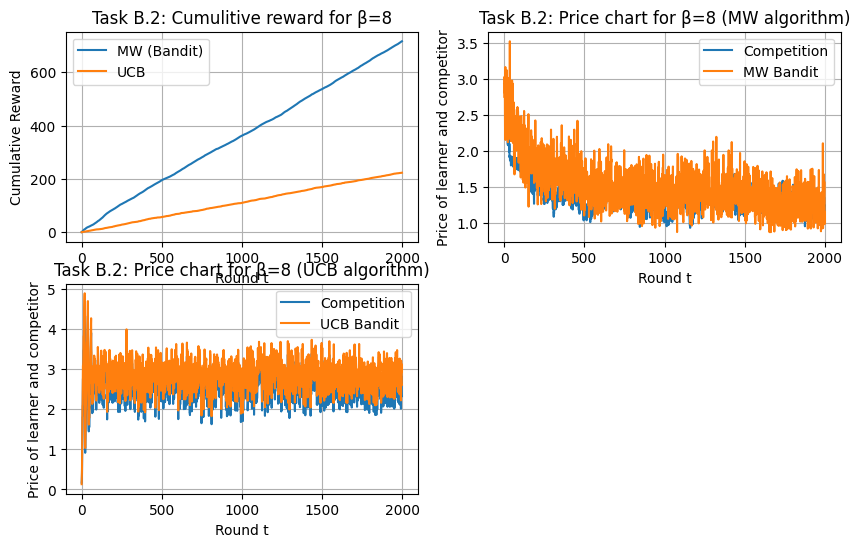

Final Cumulative Rewards (Mean ± Std):
MW:  716.25 ± 75.98
UCB: 223.15 ± 23.56


In [58]:
plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task B.2: Cumulitive reward for β=8')
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(mean_selection_comp_mw, label='Competition')
plt.plot(mean_selection_mw, label='MW Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=8 (MW algorithm)')
plt.legend()
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(mean_selection_comp_ucb, label='Competition')
plt.plot(mean_selection_ucb, label='UCB Bandit')

plt.xlabel('Round t')
plt.ylabel('Price of learner and competitor')
plt.title('Task B.2: Price chart for β=8 (UCB algorithm)')
plt.legend()
plt.grid(True)

plt.show()

print("Final Cumulative Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")